# Notebook 9 — Self-pay cash vs the LOB ladder (73721, outpatient)

**Purpose.** Overlay the self-pay **cash** price for outpatient 73721 against the
**negotiated-rate ladder** (commercial / Medicare / Medicaid / ACA rungs) at each
of the five DFW hospitals. The payoff question: *where does a cash-paying patient
sit relative to what insurers actually pay?*

**Built on (verify before trusting):**
- **v4 classifier — GREEN as of Day 13/14.** Molina/MCDSTAR fix applied, saved,
  smoke test `v4 ALL PASS`, notebook verification confirmed (row 66 → `medicaid_star`,
  MCA `unknown` → 0, global `unknown` 6 → 5). The rungs below are v4-labelled.
- **Cash anchor — Notebook 8 final table** (outpatient, unilateral, min-gross collapse).
  Carried in Step 4 with provenance.

**Cell legend:**
- **▶ RUN IN ENV** — needs the DuckDB files; runs in your environment.
- **✓ TESTED (Day 14)** — DB-independent logic, already exercised against a synthetic
  rates frame using the real `add_lob_v4`. Runs as-is once `rates` exists.


## Step 0 — Setup  ▶ RUN IN ENV

Finds the project root by walking up to `src/queries.py` (the notebook lives in a
subdir, so `cwd` isn't the root — that was the `ModuleNotFoundError`). Then globs
`data/raw/*.duckdb` exactly like Notebook 8 and maps each long filename stem to a
clean hospital label (`Baylor / MCA / Methodist / Parkland / THP`) by keyword, so the
labels line up with the Step 4 cash anchor. The cell prints the mapping — eyeball it.

In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Find the project root by walking UP until we see src/queries.py, instead of
# assuming cwd. This notebook lives in a subdir, so Path.cwd() is NOT the root
# and `from src.queries ...` would fail with ModuleNotFoundError.
def find_project_root(start=None, marker="src/queries.py", max_up=6):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents][:max_up + 1]:
        if (cand / marker).exists():
            return cand
    raise FileNotFoundError(f"Could not find {marker} above {p}")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)

from src.queries import add_lob_v4, query_procedure_rates_agg

TARGET_CODE = "73721"
SETTING     = "outpatient"   # query_procedure_rates_agg filters setting_normalized

# Same source as Notebook 8: glob data/raw/*.duckdb (one DB per hospital).
DB_GLOB  = str(PROJECT_ROOT / "data" / "raw" / "*.duckdb")
db_paths = sorted(glob.glob(DB_GLOB))
assert db_paths, f"No DuckDBs matched {DB_GLOB!r} -- fix DB_GLOB"

# Hospital label from filename stem via keyword match (stems are long, e.g.
# "medical_city_alliance_hospital-77912_parsed"). First keyword that appears wins.
LABEL_RULES = [
    ("baylor",       "Baylor"),
    ("medical_city", "MCA"),        # Medical City Alliance
    ("methodist",    "Methodist"),
    ("parkland",     "Parkland"),
    ("presbyterian", "THP"),        # Texas Health Presbyterian
    ("texas_health", "THP"),
]
def _label(stem):
    s = stem.lower()
    for kw, lab in LABEL_RULES:
        if kw in s:
            return lab
    return stem  # fallback: raw stem (prints, and the CASH_ANCHOR join will flag it)

DB_PATHS = {_label(Path(p).stem): p for p in db_paths}
assert len(DB_PATHS) == len(db_paths), "Two DBs mapped to the same label -- fix LABEL_RULES"

print(f"{len(DB_PATHS)} DBs:")
for label, p in DB_PATHS.items():
    print(f"  {label:10s} <- {Path(p).name}")

PROJECT_ROOT: C:\Users\kedha\Documents\dfw-hospital-pricing
5 DBs:
  Baylor     <- baylor_university_medical_center-69947_parsed.duckdb
  MCA        <- medical_city_alliance_hospital-77912_parsed.duckdb
  Methodist  <- methodist_dallas_medical_center-6000b_parsed.duckdb
  Parkland   <- parkland_health-6e88d_parsed.duckdb
  THP        <- texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb


## Step 1 — Pull the negotiated rungs  ▶ RUN IN ENV

`query_procedure_rates_agg` reads `standard_charge_details` (the per-payer×plan grain)
and filters `(cpt = ? OR hcpcs = ?)` and `setting_normalized = ?`. Two heterogeneities
from Notebook 8 are already handled *inside the query*, so they don't bite here:
- **Code column** — the `cpt OR hcpcs` OR-filter catches Baylor's `hcpcs` filing.
- **THP / setting casing** — we filter the *normalized* `setting_normalized` column, and
  the rungs come from `standard_charge_details` (which THP fully populates — 90 rows),
  so THP's missing charge-level row is a *cash*-anchor issue only, not a ladder issue.

In [2]:
frames = []
for label, path in DB_PATHS.items():
    con = duckdb.connect(path, read_only=True)
    try:
        df = query_procedure_rates_agg(con, TARGET_CODE, SETTING)
    finally:
        con.close()
    df.insert(0, "hospital", label)
    frames.append(df)
    print(f"{label:10s} {len(df):4d} rows")

rates = pd.concat(frames, ignore_index=True)
print("\nTOTAL rate rows:", len(rates))
rates.head()

Baylor       45 rows
MCA          46 rows
Methodist    82 rows
Parkland     65 rows
THP          40 rows

TOTAL rate rows: 278


,hospital,payer_name,plan_name,payer_group,payer_type,methodology_normalized,billing_class_normalized,n_charge_ids,dollar_rate,dollar_min,dollar_max,pct_rate,gross_min,gross_max,descriptions
0,Baylor,Baylor Scott & White Health Plan,Medicare Advantage,Other,Other,fee schedule,facility,4,212.90,212.90,212.90,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM LT | HC MRI EXT LOWER J...
1,Baylor,Blue Cross Blue Shield,Medicare Advantage,BCBS,Commercial,fee schedule,facility,4,235.30,235.30,235.30,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM LT | HC MRI EXT LOWER J...
2,Baylor,Cigna,Local Plus/Market Solutions,Cigna,Commercial,fee schedule,facility,4,1868.00,1868.00,1868.00,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM LT | HC MR LWR EXT JT W...
3,Baylor,United Healthcare,Commercial Broad,UnitedHealthcare,Commercial,fee schedule,facility,4,2620.00,2620.00,2620.00,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM BI | HC MR LWR EXT JT W...
4,Baylor,Baylor Scott & White Health Plan,BSW Plus - Small Group,Other,Other,fee schedule,facility,4,369.76,369.76,369.76,NaN,3409.3,3409.3,HC MR LWR EXT JT WO CM RT | HC MR LWR EXT JT W...


## Step 1b — SEE FIRST, before any filter  ✓ TESTED (Day 14)

Notebook 8's hardest-won lesson: *don't filter before you've seen the values.* Before
collapsing to rungs, look at (a) the v4 LOB spread, (b) how many rows are dollar-priced
vs percentage-of-charges only, (c) the `billing_class_normalized` values (facility vs
professional), and (d) per-hospital coverage. Each of these is a decision we make
*after* seeing it, not before.

In [3]:
rates = add_lob_v4(rates)

print("=== LOB distribution (v4) ===")
print(rates["lob"].value_counts(), "\n")

print("=== dollar-priced vs pct-only ===")
print("dollar rows:", rates["dollar_rate"].notna().sum(),
      "| pct-only rows:", rates["dollar_rate"].isna().sum(), "\n")

print("=== billing_class_normalized ===")
print(rates["billing_class_normalized"].value_counts(dropna=False), "\n")

print("=== methodology_normalized ===")
print(rates["methodology_normalized"].value_counts(dropna=False), "\n")

print("=== per-hospital x lob coverage ===")
print(rates.groupby(["hospital","lob"]).size().unstack(fill_value=0))

=== LOB distribution (v4) ===
lob
commercial              95
medicare_advantage      73
medicaid_chip           24
tpa_self_funded         16
medicaid_star           15
aca_exchange            12
medicaid_other          12
medicaid_star_plus       8
employer_captive         7
workers_comp             6
unknown                  5
federal_other            3
commercial_specialty     2
Name: count, dtype: int64 

=== dollar-priced vs pct-only ===
dollar rows: 239 | pct-only rows: 39 

=== billing_class_normalized ===
billing_class_normalized
None        168
facility    110
Name: count, dtype: int64 

=== methodology_normalized ===
methodology_normalized
fee schedule                       181
percent of total billed charges     51
other                               34
per diem                            11
case rate                            1
Name: count, dtype: int64 

=== per-hospital x lob coverage ===
lob        aca_exchange  commercial  commercial_specialty  employer_captive  federa

## Step 2 — Methodology alignment  ✓ TESTED (Day 14) · DECISION NEEDED

Step 1b surfaced what the original default assumed away: `billing_class_normalized` is
**NULL for 168 of 278 rows** and `facility` for 110 — there is **no `professional`
class**, just tagged-facility vs untagged. So a "facility-only" filter wouldn't isolate
a professional component; it would silently drop ~60% of rows (the untagged hospital
rates) and likely empty out whole hospital×LOB cells.

Two decisions to log (continue from **Decision 28**):

- **Decision 29 — billing class.** The diagnostic cell shows, per hospital, dollar-priced
  coverage under *all classes* vs *facility-only*. Default is `BILLING_CLASS = None`
  (keep all) — the NULLs are untagged hospital rates, not a professional component.
  Flip to `["facility"]` **only if** the diagnostic shows facility is well-populated for
  *every* hospital.
- **Decision 30 — dollar vs percent.** 239 dollar rows vs 39 pct-only. Primary ladder
  uses `dollar_rate`; the pct proxy stays commented.

In [4]:
# Decision 29 diagnostic — does facility-only starve any hospital?
# (Step 1b showed billing_class_normalized is mostly NULL/untagged, not professional.)
print("billing_class by hospital:")
print(pd.crosstab(rates["hospital"],
                  rates["billing_class_normalized"].fillna("NULL")), "\n")

d_all = rates[rates["dollar_rate"].notna()]
d_fac = d_all[d_all["billing_class_normalized"] == "facility"]
cov = pd.DataFrame({
    "dollar_all_classes":   d_all.groupby("hospital").size(),
    "dollar_facility_only": d_fac.groupby("hospital").size(),
}).fillna(0).astype(int)
print("dollar-priced coverage per hospital:")
print(cov)

billing_class by hospital:
billing_class_normalized  NULL  facility
hospital                                
Baylor                       0        45
MCA                         46         0
Methodist                   82         0
Parkland                     0        65
THP                         40         0 

dollar-priced coverage per hospital:
           dollar_all_classes  dollar_facility_only
hospital                                           
Baylor                     45                    45
MCA                        34                     0
Methodist                  82                     0
Parkland                   43                    43
THP                        35                     0


In [5]:
# Decision 29 — billing-class policy (set AFTER reading the diagnostic above):
#   None         -> keep all billing classes (default; facility is mostly untagged here)
#   ["facility"] -> facility-tagged rows only (use ONLY if facility is well populated
#                   for EVERY hospital in the diagnostic)
BILLING_CLASS = None

# Decision 30 — dollar-priced rows form the primary ladder (pct-only excluded).
dollar = rates[rates["dollar_rate"].notna()].copy()
if BILLING_CLASS is not None:
    dollar = dollar[dollar["billing_class_normalized"].isin(BILLING_CLASS)]
print(f"ladder rows: {len(dollar)}  (of {len(rates)} total)")

# --- optional pct proxy (Decision 30 alternative) -------------------------
# pct_only = rates[rates["dollar_rate"].isna() & rates["pct_rate"].notna()].copy()
# pct_only["dollar_rate"] = pct_only["pct_rate"]/100.0 * pct_only["gross_min"]
# dollar = pd.concat([dollar, pct_only], ignore_index=True)
# --------------------------------------------------------------------------
dollar[["hospital","lob","dollar_rate"]].head()

ladder rows: 239  (of 278 total)


,hospital,lob,dollar_rate
0,Baylor,medicare_advantage,212.90
1,Baylor,medicare_advantage,235.30
2,Baylor,commercial,1868.00
3,Baylor,commercial,2620.00
4,Baylor,employer_captive,369.76


## Step 3 — Collapse to rungs  ✓ TESTED (Day 14)

One rung per (hospital, LOB) = median dollar rate. Pivot to a hospital × LOB matrix
for a readable ladder.

In [6]:
rungs = (dollar.groupby(["hospital","lob"])["dollar_rate"]
               .median().reset_index())
pivot = rungs.pivot(index="hospital", columns="lob", values="dollar_rate")
print(pivot.round(2))

lob        aca_exchange  commercial  employer_captive  federal_other  medicaid_chip  medicaid_other  medicaid_star  medicaid_star_plus  medicare_advantage  tpa_self_funded  unknown  workers_comp
hospital                                                                                                                                                                                          
Baylor           463.89     1944.56            369.76         224.10         210.84          210.84            NaN                 NaN              235.30          2556.98  1875.12        234.77
MCA              313.62      906.53               NaN            NaN         208.84          219.28         208.84              220.32                 NaN              NaN      NaN           NaN
Methodist        232.47     1518.00            912.24         232.47         232.47             NaN        1075.92              862.76              232.47           232.47   232.47        232.47
Parkland         678.20  

## Step 4 — The cash anchor  ✓ TESTED (Day 14)

From **Notebook 8** (outpatient 73721, unilateral, min-gross-per-hospital collapse).
Carried as data with provenance so it isn't a magic number.

| Hospital | Cash | Source table | Note |
|---|---|---|---|
| Baylor | $2,045.58 | standard_charges | 60% of gross |
| Parkland | $2,426.80 | standard_charges | 40% of gross |
| Methodist | $2,439.00 | standard_charges | 50% of gross |
| THP | $3,139.20 | **standard_charge_details (fallback)** | 60% of gross |
| MCA | $8,363.98 | standard_charges | **cash == gross (no discount)** |

In [7]:
CASH_ANCHOR = pd.DataFrame(
    [("Baylor", 2045.58), ("Parkland", 2426.80), ("Methodist", 2439.00),
     ("THP", 3139.20), ("MCA", 8363.98)],
    columns=["hospital", "cash"],
).set_index("hospital")
CASH_ANCHOR

,cash
hospital,
Baylor,2045.58
Parkland,2426.80
Methodist,2439.00
THP,3139.20
MCA,8363.98


## Step 4b — Overlay: cash vs the rungs  ✓ TESTED (Day 14)

Per hospital, place cash against the Medicaid / Medicare / commercial rungs.

**Medicare rung note:** in the current 73721 data every Medicare row has a *carrier*
payer, so v4 routes them all to `medicare_advantage` — there is no traditional FFS
rung. The helper anchors the multiple on `medicare_traditional` if present, else
`medicare_advantage`. (Keeps the metric meaningful now and still correct once the
basket extension reaches a code that publishes a CMS FFS line.)

In [12]:
MEDICAID_LOBS = ["medicaid_chip", "medicaid_star", "medicaid_star_plus", "medicaid_other"]
MEDICARE_LOBS = ["medicare_traditional", "medicare_advantage"] 

def _family_rung(df, lobs):
    return df[df["lob"].isin(lobs)].groupby("hospital")["dollar_rate"].median()

commercial_rung = dollar[dollar["lob"] == "commercial"].groupby("hospital")["dollar_rate"].median()
medicaid_rung   = _family_rung(dollar, MEDICAID_LOBS)
medicare_rung   = _family_rung(dollar, MEDICARE_LOBS)

overlay = CASH_ANCHOR.copy()
overlay["medicaid"]   = medicaid_rung
overlay["medicare"]   = medicare_rung
overlay["commercial"] = commercial_rung

overlay["cash_x_medicaid"]       = overlay["cash"] / overlay["medicaid"]
overlay["cash_x_medicare"]       = overlay["cash"] / overlay["medicare"]
overlay["cash_vs_commercial"]    = overlay["cash"] / overlay["commercial"]
overlay["cash_above_commercial"] = overlay["cash"] > overlay["commercial"]

cols = ["cash","medicaid","medicare","commercial",
        "cash_x_medicaid","cash_x_medicare","cash_vs_commercial","cash_above_commercial"]
overlay[cols].round(2)

,cash,medicaid,medicare,commercial,cash_x_medicaid,cash_x_medicare,cash_vs_commercial,cash_above_commercial
hospital,,,,,,,,
Baylor,2045.58,210.84,235.30,1944.56,9.70,8.69,1.05,True
Parkland,2426.80,219.30,1274.07,3937.50,11.07,1.90,0.62,False
Methodist,2439.00,862.76,232.47,1518.00,2.83,10.49,1.61,True
THP,3139.20,NaN,226.38,1262.69,NaN,13.87,2.49,True
MCA,8363.98,208.84,NaN,906.53,40.05,NaN,9.23,True


In [10]:
# --- Step 4c: integrity drill-down before writing findings ---
# 1) Are Parkland's high rungs real, or driven by one outlier?
pk = dollar[dollar["hospital"] == "Parkland"]
print("Parkland rungs by lob (count / median / min / max):")
print(pk.groupby("lob")["dollar_rate"].agg(["count", "median", "min", "max"]).round(2), "\n")

# 2) Confirm the NaN rungs are genuinely absent (no rows), not pct-only
print("THP lob coverage:", dict(dollar[dollar.hospital == "THP"].lob.value_counts()))
print("MCA lob coverage:", dict(dollar[dollar.hospital == "MCA"].lob.value_counts()), "\n")

# 3) Full rung pivot — eyeball Parkland against the rest
print(pivot.round(2))

Parkland rungs by lob (count / median / min / max):
                    count   median      min      max
lob                                                 
aca_exchange            1   678.20   678.20   678.20
commercial             11  3937.50  2851.50  4368.20
federal_other           1  4550.25  4550.25  4550.25
medicaid_chip           7   208.80   208.80   229.70
medicaid_other          2   783.74   229.70  1337.77
medicaid_star           8   219.30   208.80   886.70
medicaid_star_plus      3   815.70   776.90   854.60
medicare_advantage      9  1274.07  1268.00  1337.77
workers_comp            1   229.70   229.70   229.70 

THP lob coverage: {'medicare_advantage': np.int64(22), 'commercial': np.int64(12), 'aca_exchange': np.int64(1)}
MCA lob coverage: {'commercial': np.int64(15), 'medicaid_star': np.int64(6), 'medicaid_other': np.int64(5), 'medicaid_chip': np.int64(5), 'medicaid_star_plus': np.int64(2), 'aca_exchange': np.int64(1)} 

lob        aca_exchange  commercial  employer_c

## Step 5 — Visualize the ladder  ✓ TESTED (Day 14)

Log-x dot plot: one row per hospital, a dot per LOB rung, the self-pay cash marked as a
red diamond. Log scale because Medicaid (~$300) and MCA cash (~$8.4K) span ~30×.

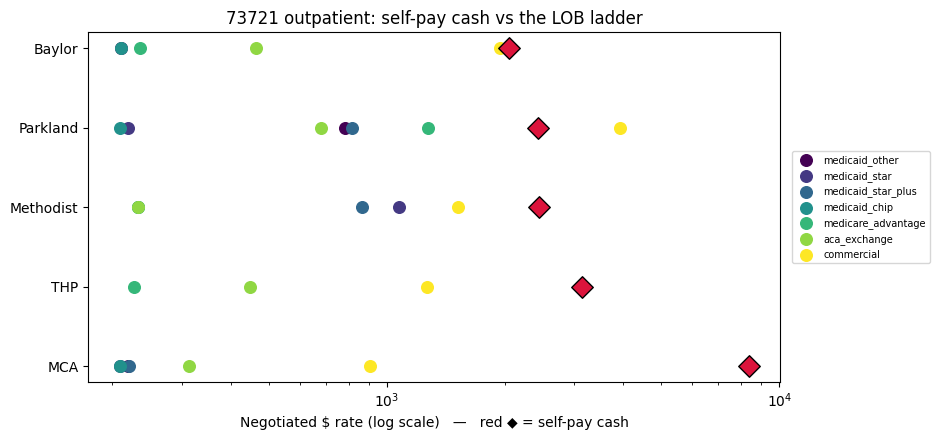

In [14]:
LOB_FAMILIES = ["medicaid_other","medicaid_star","medicaid_star_plus","medicaid_chip",
                "medicare_traditional","medicare_advantage","aca_exchange","commercial"]
present = [c for c in LOB_FAMILIES if c in pivot.columns]
hosp_order = list(CASH_ANCHOR.sort_values("cash", ascending=False).index)
ymap = {h: i for i, h in enumerate(hosp_order)}
cmap = plt.cm.viridis(np.linspace(0, 1, len(present)))

fig, ax = plt.subplots(figsize=(9.5, 4.5))
for ci, lob in enumerate(present):
    xs, ys = [], []
    for h in hosp_order:
        if h in pivot.index and pd.notna(pivot.loc[h, lob]):
            xs.append(pivot.loc[h, lob]); ys.append(ymap[h])
    ax.scatter(xs, ys, s=70, color=cmap[ci], label=lob, zorder=3)
for h in hosp_order:
    ax.scatter(CASH_ANCHOR.loc[h, "cash"], ymap[h], marker="D", s=120,
               color="crimson", edgecolor="black", zorder=5)
ax.set_yticks(range(len(hosp_order))); ax.set_yticklabels(hosp_order)
ax.set_xscale("log")
ax.set_xlabel("Negotiated $ rate (log scale)   —   red \u25c6 = self-pay cash")
ax.set_title(f"{TARGET_CODE} {SETTING}: self-pay cash vs the LOB ladder")
ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); plt.show()

## Findings & caveats  (fill after running)

**Findings — fill from your output:**
- Where does cash land per hospital? (above / below / between which rungs)
- `cash_x_medicare` per hospital — how many × the Medicare(-MA) rate is self-pay?
- Is cash above the commercial rung anywhere besides MCA?
- MCA: cash == gross, so expect it to sit at/above its top negotiated rung — quantify.

**Caveats to carry into any writeup:**
- **MCA cash == gross** — unverified against MCA's source MRF (consistent across all 3
  priced rows on Day 13, so likely as-published). Spot-check before asserting as fact.
- **THP cash came via the `standard_charge_details` fallback** (Day 13, gated on Baylor's
  cross-table equality). Methodology note, not an error.
- **No traditional-Medicare rung** — all Medicare rows are carrier MA in this data; the
  Medicare multiple anchors on MA. Re-examine when the basket extends.
- **Billing-class / dollar-vs-pct filters (Decisions 29/30)** shape which rungs survive —
  state them explicitly.

**Open items / next:**
- Log Decisions 29 (billing class) + 30 (dollar vs pct) once the Step-1b values are set.
- MCA 2.6× vs ~3.9× reconciliation (still open from Day 13) — feeds the MCA outlier read here.
- Basket extension beyond 73721; CMS OPPS swap (v1.1) for a true Medicare FFS rung.
